In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error, mean_absolute_percentage_error

In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
#Loading data
df=pd.read_excel("/content/drive/MyDrive/premiums.xlsx")

In [83]:
#First 5 rows of data
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [84]:
#Last 5 rows of data
df.tail()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490
49999,48,Female,Southwest,Married,3,Normal,Occasional,Self-Employed,<10L,7,Diabetes,Silver,19730


In [85]:
#No. of rows and columns
df.shape

(50000, 13)

In [86]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    50000 non-null  int64 
 1   Gender                 50000 non-null  object
 2   Region                 50000 non-null  object
 3   Marital_status         50000 non-null  object
 4   Number Of Dependants   50000 non-null  int64 
 5   BMI_Category           50000 non-null  object
 6   Smoking_Status         49989 non-null  object
 7   Employment_Status      49998 non-null  object
 8   Income_Level           49987 non-null  object
 9   Income_Lakhs           50000 non-null  int64 
 10  Medical History        50000 non-null  object
 11  Insurance_Plan         50000 non-null  object
 12  Annual_Premium_Amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


In [88]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [89]:
#checking for missing values
df.isnull().sum()

,0
Age,0
Gender,0
Region,0
Marital_status,0
Number Of Dependants,0
BMI_Category,0
Smoking_Status,11
Employment_Status,2
Income_Level,13
Income_Lakhs,0


In [90]:
df['Smoking_Status'] = df['Smoking_Status'].fillna(df['Smoking_Status'].mode()[0])
df['Employment_Status'] = df['Employment_Status'].fillna(df['Employment_Status'].mode()[0])
df['Income_Level'] = df['Income_Level'].fillna(df['Income_Level'].mode()[0])

In [91]:
df.isnull().sum()

,0
Age,0
Gender,0
Region,0
Marital_status,0
Number Of Dependants,0
BMI_Category,0
Smoking_Status,0
Employment_Status,0
Income_Level,0
Income_Lakhs,0


In [92]:
invalid_values = ['NA', 'na', '', ' ']
df = df[~df.isin(invalid_values).any(axis=1)]
df.dropna(inplace=True)

In [93]:
# Detect and remove outliers using IQR for all numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

df_clean = df.copy()
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


In [94]:
df_clean.shape

(46376, 13)

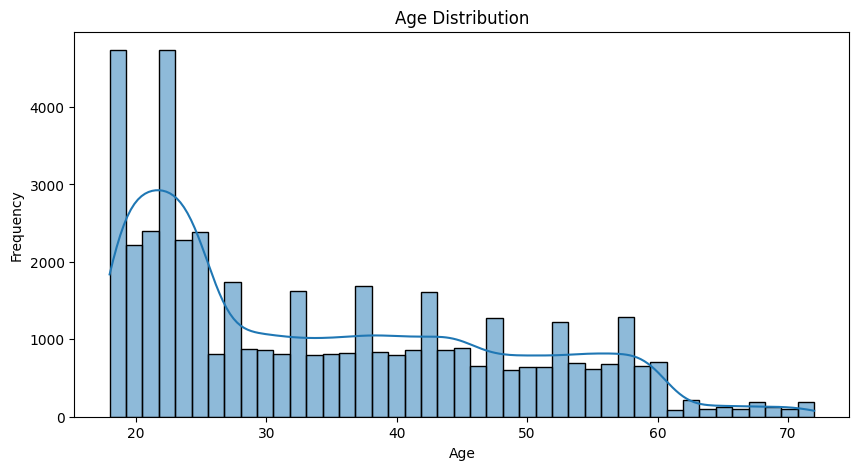

In [95]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Age'],kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [96]:
df_clean['Age'].value_counts()

,count
Age,
22,2423
21,2401
25,2389
18,2368
19,2366
23,2313
24,2289
20,2212
45,888


In [97]:
df_clean['Age'].max()

72

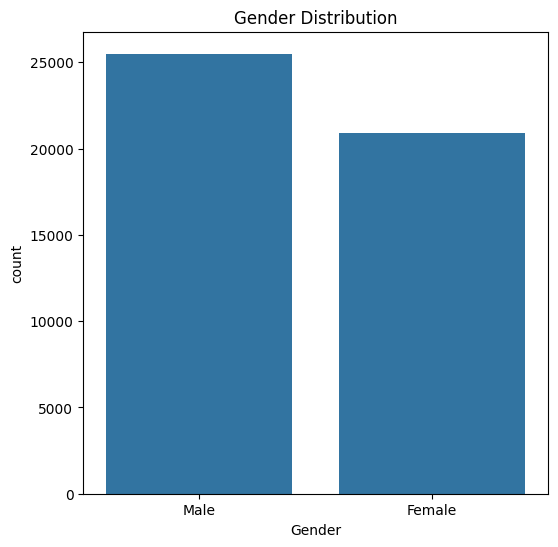

In [98]:
# Gender column
plt.figure(figsize=(6,6))
sns.countplot(x='Gender', data=df_clean)
plt.title('Gender Distribution')
plt.show()

In [99]:
df_clean['Gender'].value_counts()

,count
Gender,
Male,25491
Female,20885


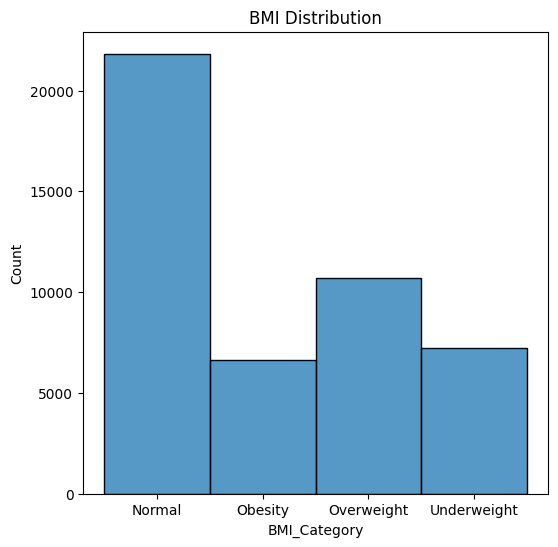

In [100]:
# bmi distribution
plt.figure(figsize=(6,6))
sns.histplot(df_clean['BMI_Category'])
plt.title('BMI Distribution')
plt.show()

/tmp/ipython-input-1472545350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Region', palette='Set2')


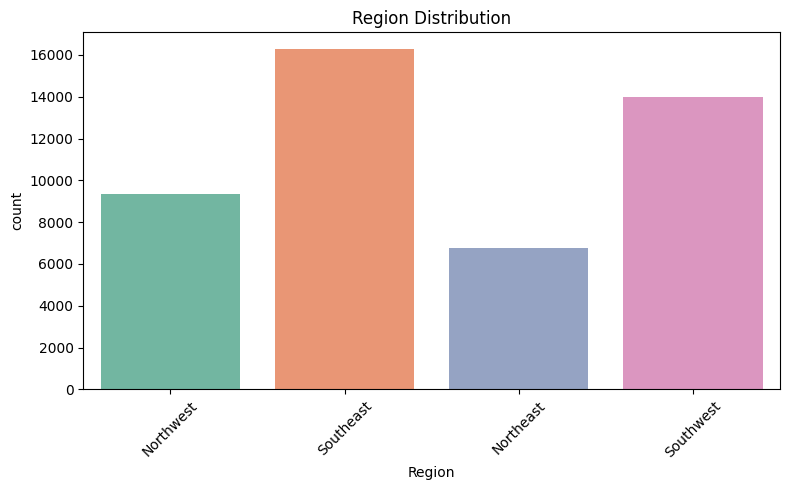

In [101]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='Region', palette='Set2')
plt.title("Region Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3892448768.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Marital_status', palette='pastel')


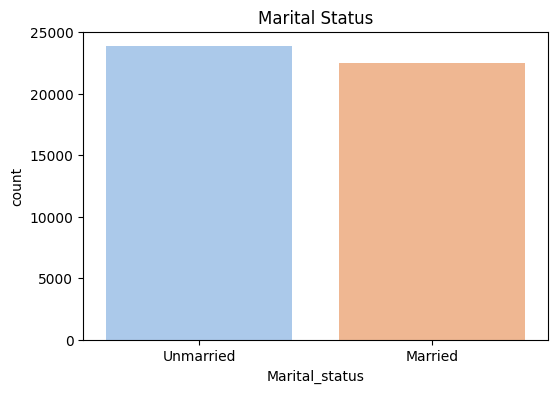

In [102]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='Marital_status', palette='pastel')
plt.title("Marital Status")
plt.show()

/tmp/ipython-input-3558838892.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Number Of Dependants', palette='Set3')


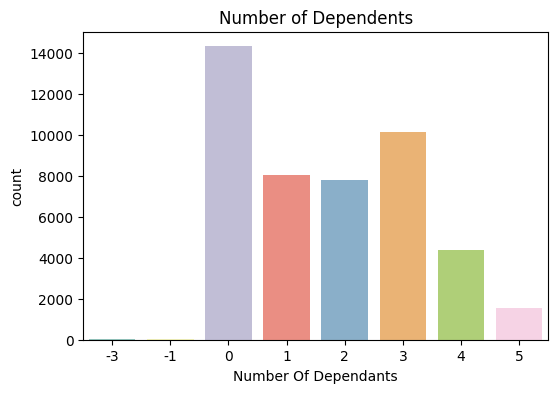

In [103]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='Number Of Dependants', palette='Set3')
plt.title("Number of Dependents")
plt.show()

In [104]:
df_clean['Number Of Dependants'].value_counts()

,count
Number Of Dependants,
0,14326
3,10169
1,8069
2,7819
4,4386
5,1537
-1,40
-3,30


In [105]:
df_clean['Number Of Dependants']=df_clean['Number Of Dependants'].abs()

In [106]:
df_clean['Number Of Dependants'].value_counts()

,count
Number Of Dependants,
0,14326
3,10199
1,8109
2,7819
4,4386
5,1537


/tmp/ipython-input-796224789.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Smoking_Status', palette='coolwarm')


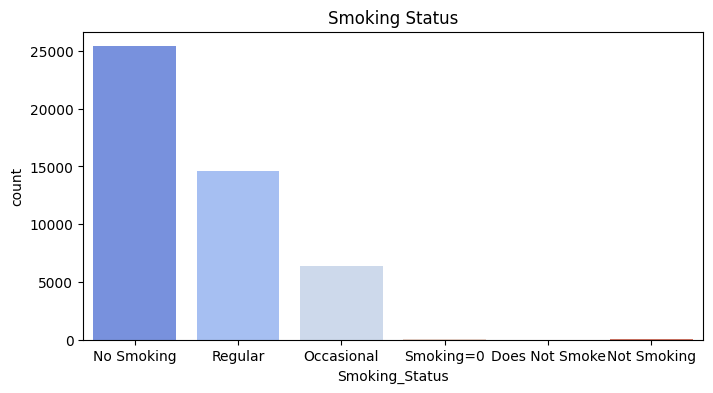

In [107]:
plt.figure(figsize=(8,4))
sns.countplot(data=df_clean, x='Smoking_Status', palette='coolwarm')
plt.title("Smoking Status")
plt.show()

In [108]:
df_clean['Smoking_Status'].value_counts()

,count
Smoking_Status,
No Smoking,25396
Regular,14577
Occasional,6381
Smoking=0,8
Not Smoking,8
Does Not Smoke,6


In [109]:
df_clean['Smoking_Status'] = df_clean['Smoking_Status'].replace({
    'Smoking=0': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Not Smoking': 'No Smoking'
})


In [110]:
df_clean['Smoking_Status'].value_counts()

,count
Smoking_Status,
No Smoking,25418
Regular,14577
Occasional,6381


/tmp/ipython-input-892500240.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Employment_Status', palette='cubehelix')


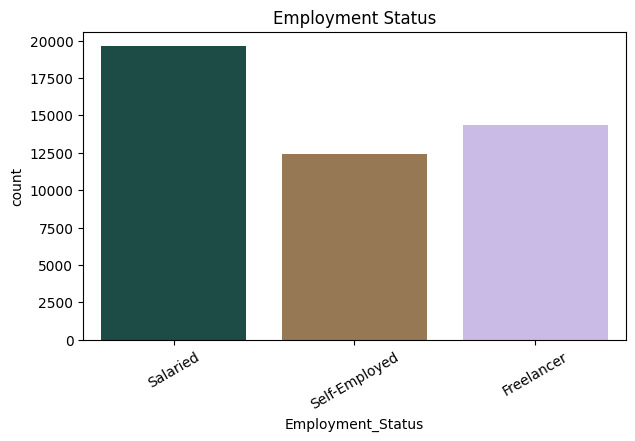

In [111]:
plt.figure(figsize=(7,4))
sns.countplot(data=df_clean, x='Employment_Status', palette='cubehelix')
plt.title("Employment Status")
plt.xticks(rotation=30)
plt.show()

In [112]:
df_clean['Employment_Status'].value_counts()

,count
Employment_Status,
Salaried,19606
Freelancer,14376
Self-Employed,12394


/tmp/ipython-input-1063287691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Income_Level', palette='YlGnBu')


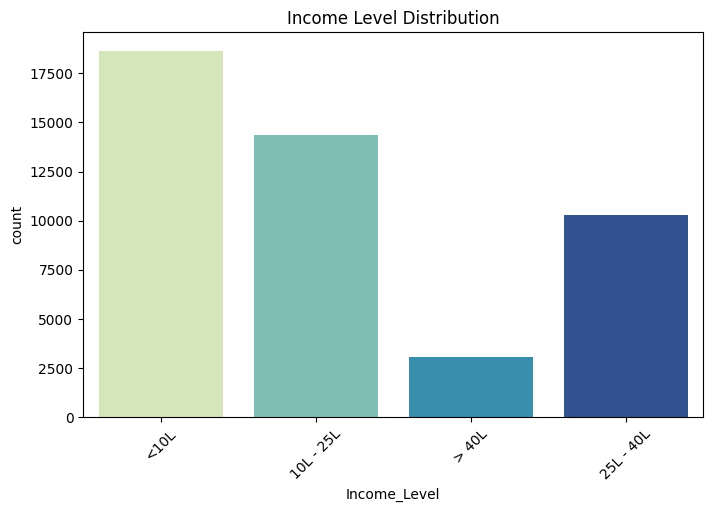

In [113]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='Income_Level', palette='YlGnBu')
plt.title("Income Level Distribution")
plt.xticks(rotation=45)
plt.show()

In [114]:
df_clean['Income_Level'].value_counts()

,count
Income_Level,
<10L,18658
10L - 25L,14367
25L - 40L,10277
> 40L,3074


/tmp/ipython-input-1620086229.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Income_Lakhs', palette='YlGnBu')


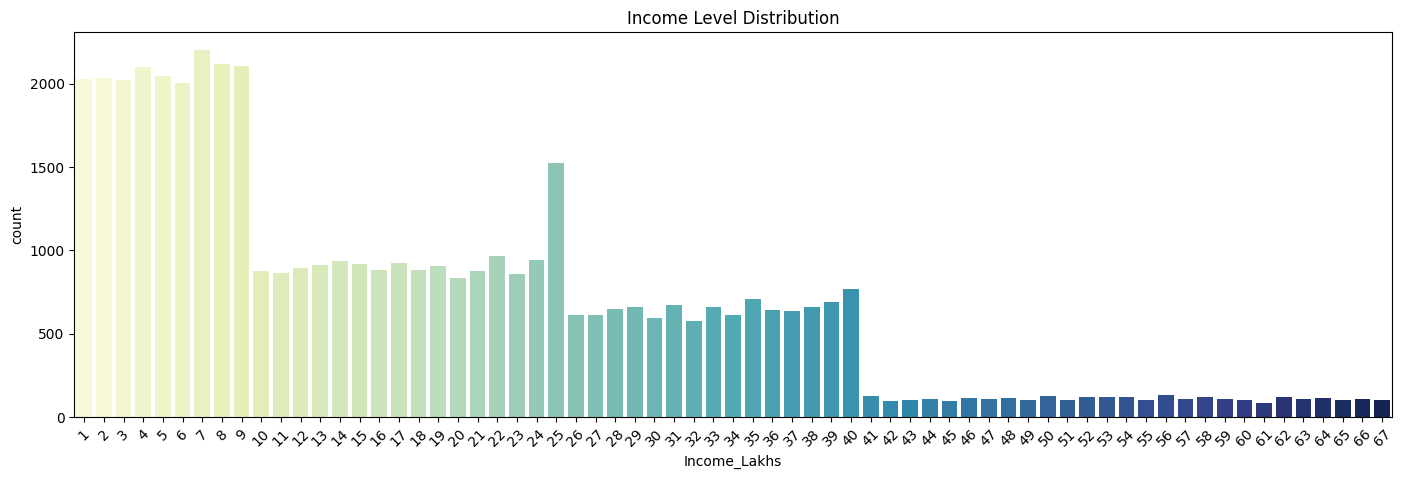

In [115]:
plt.figure(figsize=(17,5))
sns.countplot(data=df_clean, x='Income_Lakhs', palette='YlGnBu')
plt.title("Income Level Distribution")
plt.xticks(rotation=45)
plt.show()

In [116]:
df_clean['Income_Lakhs'].value_counts()

,count
Income_Lakhs,
7,2199
8,2115
9,2105
4,2101
5,2048
...,...
43,101
65,100
45,99


/tmp/ipython-input-1040027353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Medical History', palette='Oranges')


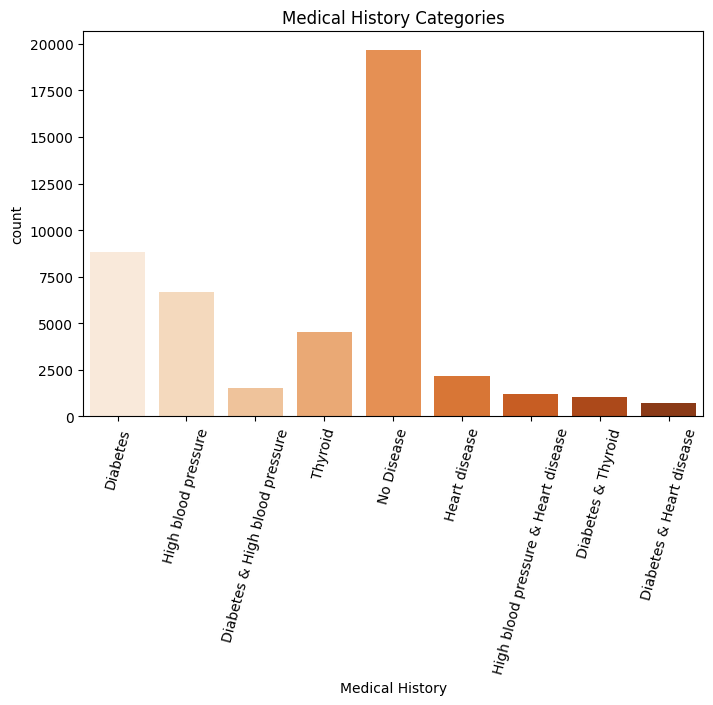

In [117]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='Medical History', palette='Oranges')
plt.title("Medical History Categories")
plt.xticks(rotation=75)
plt.show()

In [118]:
df_clean['Medical History'].value_counts()

,count
Medical History,
No Disease,19683
Diabetes,8826
High blood pressure,6684
Thyroid,4550
Heart disease,2176
Diabetes & High blood pressure,1530
High blood pressure & Heart disease,1191
Diabetes & Thyroid,1041
Diabetes & Heart disease,695


/tmp/ipython-input-2275878891.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Insurance_Plan', palette='PuBuGn')


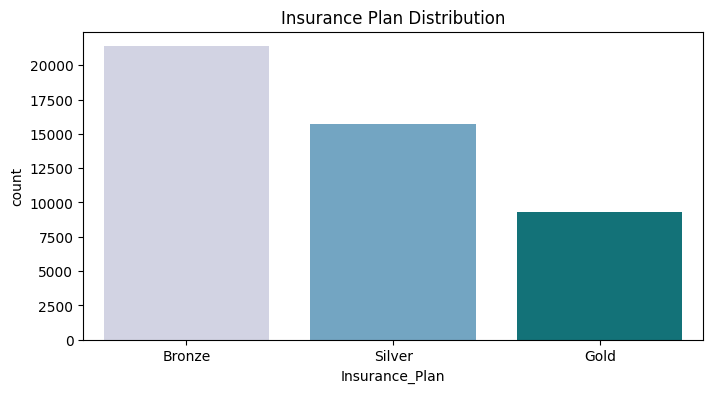

In [119]:
plt.figure(figsize=(8,4))
sns.countplot(data=df_clean, x='Insurance_Plan', palette='PuBuGn')
plt.title("Insurance Plan Distribution")
plt.show()


In [120]:
df_clean['Insurance_Plan'].value_counts()

,count
Insurance_Plan,
Bronze,21382
Silver,15682
Gold,9312


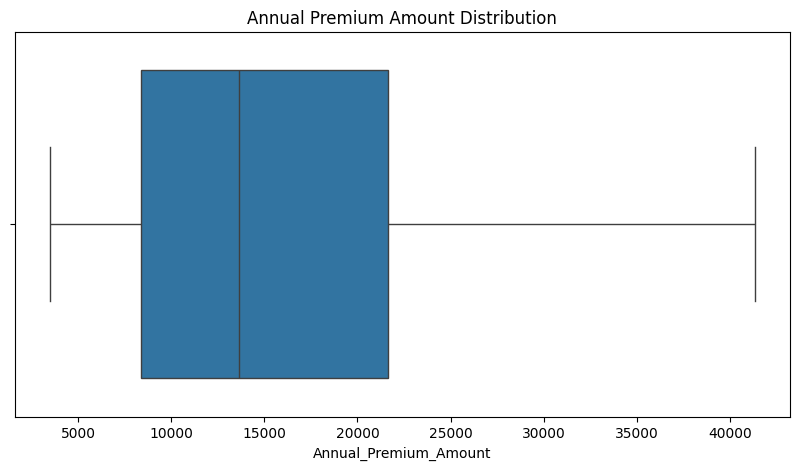

In [121]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['Annual_Premium_Amount'])
plt.title('Annual Premium Amount Distribution')
plt.show()

In [122]:
df_clean['Annual_Premium_Amount'].value_counts()

,count
Annual_Premium_Amount,
9564,11
7821,10
8351,10
16056,10
9388,9
...,...
30017,1
5638,1
12545,1


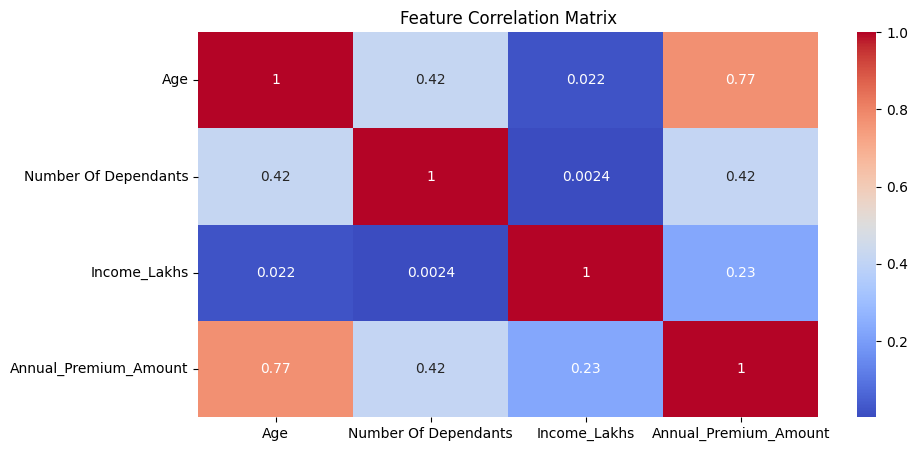

In [123]:
plt.figure(figsize=(10,5))
sns.heatmap(df_clean.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [124]:
# converting categorical columns to numeric values

# Gender
df_clean['Gender_flag'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})

In [125]:

# Region
df_clean['Region_flag'] = df_clean['Region'].map({
    'Northwest': 0, 'Southeast': 1, 'Northeast': 2, 'Southwest': 3
})

In [126]:
# Marital_status
df_clean['Marital_status_flag'] = df_clean['Marital_status'].map({
    'Unmarried': 0, 'Married': 1
})


In [127]:
# BMI_Category
df_clean['BMI_Category_flag'] = df_clean['BMI_Category'].map({
    'Normal': 0, 'Underweight': 1, 'Overweight': 2, 'Obesity': 3
})

In [128]:
# Smoking_Status
df_clean['Smoking_Status_flag'] = df_clean['Smoking_Status'].map({
    'No Smoking': 0,'Occasional': 1,'Regular': 2
})

In [129]:
# Employment_Status
df_clean['Employment_Status_flag'] = df_clean['Employment_Status'].map({
     'Salaried': 0, 'Self-Employed': 1,'Freelancer':2
})

In [130]:
# Income_Level
df_clean['Income_Level_flag'] = df_clean['Income_Level'].map({
    '<10L': 0,
    '10L - 25L': 1,
    '25L - 40L': 2,
    '> 40L':3
})


In [131]:
# Medical History
df_clean['Medical History flag'] = df_clean['Medical History'].map({
   'No Disease': 0,
    'Thyroid': 1,
    'High blood pressure': 2,
    'Diabetes': 3,
    'Diabetes & Thyroid': 4,
    'Diabetes & High blood pressure': 5,
    'Heart disease': 6,
    'Diabetes & Heart disease': 7,
    'High blood pressure & Heart disease': 8


})


In [132]:
# Insurance_Plan
df_clean['Insurance_Plan_flag'] = df_clean['Insurance_Plan'].map({
    'Bronze': 0, 'Silver': 1, 'Gold': 2
})

In [133]:
new_df=df_clean.drop(['Gender','Region','Marital_status','BMI_Category','Smoking_Status','Employment_Status','Income_Level','Medical History','Insurance_Plan'],axis=1)

In [134]:
new_df.head()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount,Gender_flag,Region_flag,Marital_status_flag,BMI_Category_flag,Smoking_Status_flag,Employment_Status_flag,Income_Level_flag,Medical History flag,Insurance_Plan_flag
0,26,0,6,9053,0,0,0,0,0,0,0,3,0
1,29,2,6,16339,1,1,1,3,2,0,0,3,0
2,49,2,20,18164,1,2,1,0,0,1,1,2,1
5,56,3,14,15610,0,2,1,3,1,1,1,3,0
6,33,3,4,20653,0,1,1,0,2,1,0,5,1


In [135]:
X= new_df.drop("Annual_Premium_Amount",axis=1)
y = new_df["Annual_Premium_Amount"]

In [136]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [137]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [138]:
#Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [139]:
y_pred_linear=model.predict(X_test_scaled)

In [140]:
mean_absolute_error(y_test,y_pred_linear)

1721.4871390098758

In [141]:
mean_absolute_percentage_error(y_test,y_pred_linear)

0.15899713462317114

In [142]:
mean_squared_error(y_test,y_pred_linear)

4892216.512321439

In [143]:
r2_score(y_test,y_pred_linear)

0.9293088259714277

In [144]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor()
rf_model.fit(X_train,y_train)

RandomForestRegressor()

In [145]:
y_pred_rf=rf_model.predict(X_test)

In [146]:
mean_absolute_error(y_test,y_pred_rf)

797.3974122121231

In [147]:
mean_squared_error(y_test,y_pred_rf)

1453429.1541733271

In [148]:
r2_score(y_test,y_pred_rf)

0.9789983511528779

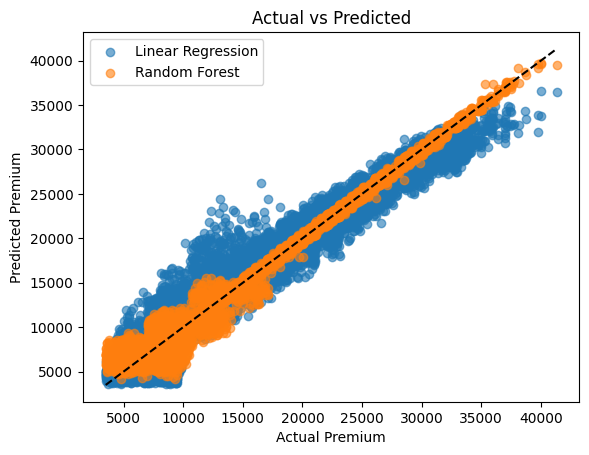

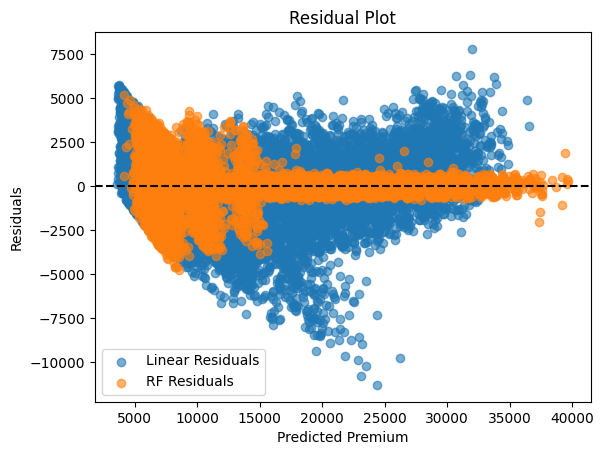

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

# Actual vs Predicted for Linear Regression
plt.scatter(y_test, y_pred_linear, label="Linear Regression", alpha=0.6)
plt.scatter(y_test, y_pred_rf, label="Random Forest", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Premium")
plt.ylabel("Predicted Premium")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# Residual Plot
plt.scatter(y_pred_linear, y_test - y_pred_linear, label="Linear Residuals", alpha=0.6)
plt.scatter(y_pred_rf, y_test - y_pred_rf, label="RF Residuals", alpha=0.6)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Predicted Premium")
plt.ylabel("Residuals")
plt.legend()
plt.title("Residual Plot")
plt.show()


In [150]:
import joblib

joblib.dump(rf_model, 'model1.pkl')


In [151]:
from google.colab import files
files.download('model1.pkl')